# 🎮 Phân Tích Xu Hướng Thị Trường Trò Chơi Điện Tử & Dự Đoán Doanh Số Bán Hàng Toàn Cầu

**Sinh viên:** Nguyễn Như Khiêm — **MSSV:** K225480106030  
**Môn học:** Khoa Học Dữ Liệu  
**GVHD:** TS. Nguyễn Văn Huy

---

## Mục tiêu
1. Phân tích xu hướng thị trường game theo thể loại, nền tảng, nhà phát hành, khu vực và thời gian
2. Xây dựng mô hình **Hồi quy** dự đoán doanh số toàn cầu
3. **Phân cụm** nhóm các trò chơi có đặc điểm doanh số tương đồng

In [1]:
# ============================================================
# 0. IMPORT THƯ VIỆN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Style toàn cục
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

# Bảng màu chính
PALETTE = ['#2D6A9F', '#E8543A', '#3DAA6E', '#F5A623', '#9B59B6',
           '#1ABC9C', '#E74C3C', '#F39C12', '#27AE60', '#8E44AD']

print('✅ Thư viện đã sẵn sàng!')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')
print(f'  sklearn OK')

✅ Thư viện đã sẵn sàng!
  pandas  2.3.3
  numpy   2.4.2
  sklearn OK


In [2]:
# ============================================================
# 1. TẢI VÀ KHÁM PHÁ DỮ LIỆU
# ============================================================
df = pd.read_csv('video_games_sales.csv')

print('='*55)
print('  THÔNG TIN BỘ DỮ LIỆU VIDEO GAME SALES')
print('='*55)
print(f'  Số lượng game   : {len(df):,}')
print(f'  Số cột          : {df.shape[1]}')
print(f'  Khoảng năm      : {int(df["Year"].min())} – {int(df["Year"].max())}')
print(f'  Số Platform     : {df["Platform"].nunique()}')
print(f'  Số thể loại     : {df["Genre"].nunique()}')
print(f'  Số nhà phát hành: {df["Publisher"].nunique()}')
print('='*55)
df.head(10)

  THÔNG TIN BỘ DỮ LIỆU VIDEO GAME SALES
  Số lượng game   : 16,598
  Số cột          : 11
  Khoảng năm      : 1980 – 2020
  Số Platform     : 31
  Số thể loại     : 12
  Số nhà phát hành: 578


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [3]:
# Kiểm tra missing values & thống kê
print('--- Missing Values ---')
print(df.isnull().sum())
print()

# Làm sạch
df.dropna(subset=['Year', 'Genre', 'Publisher'], inplace=True)
df['Year'] = df['Year'].astype(int)

print('--- Thống Kê Mô Tả ---')
df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].describe().round(2)

--- Missing Values ---
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

--- Thống Kê Mô Tả ---


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.00,16291.00,16291.00,16291.00,16291.00
mean,0.27,0.15,0.08,0.05,0.54
std,0.82,0.51,0.31,0.19,1.57
min,0.00,0.00,0.00,0.00,0.01
25%,0.00,0.00,0.00,0.00,0.06
50%,0.08,0.02,0.00,0.01,0.17
75%,0.24,0.11,0.04,0.04,0.48
max,41.49,29.02,10.22,10.57,82.74


---
## 📊 CÂU HỎI 1 — Thể loại game có doanh số cao nhất

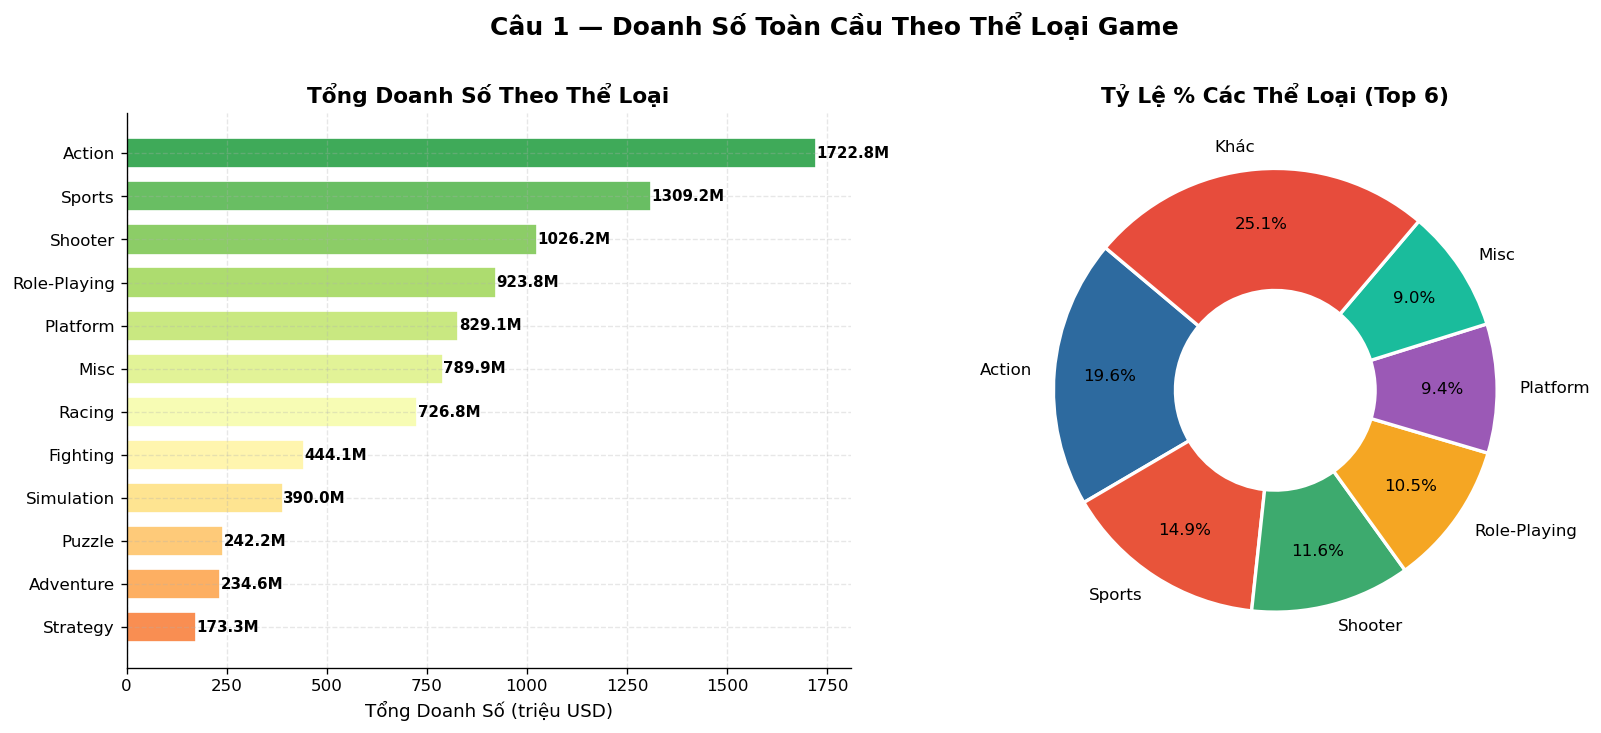


🏆 Thể loại doanh số cao nhất: Action — 1722.84 triệu USD


In [4]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Câu 1 — Doanh Số Toàn Cầu Theo Thể Loại Game', fontsize=15, fontweight='bold', y=1.01)

# Horizontal bar
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(genre_sales)))
bars = axes[0].barh(genre_sales.index, genre_sales.values, color=colors, edgecolor='white', height=0.7)
axes[0].set_xlabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Tổng Doanh Số Theo Thể Loại', fontsize=13, fontweight='bold')
for bar, val in zip(bars, genre_sales.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=9, fontweight='bold')

# Pie chart – top 6
top6 = genre_sales.sort_values(ascending=False).head(6)
other = genre_sales.sort_values(ascending=False).tail(len(genre_sales)-6).sum()
pie_data = pd.concat([top6, pd.Series({'Khác': other})])
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=PALETTE[:len(pie_data)], wedgeprops=wedge_props,
            startangle=140, pctdistance=0.75)
axes[1].set_title('Tỷ Lệ % Các Thể Loại (Top 6)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_q1_genre.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n🏆 Thể loại doanh số cao nhất: {genre_sales.idxmax()} — {genre_sales.max():.2f} triệu USD")

---
## 📊 CÂU HỎI 2 — Hệ máy bán chạy nhất

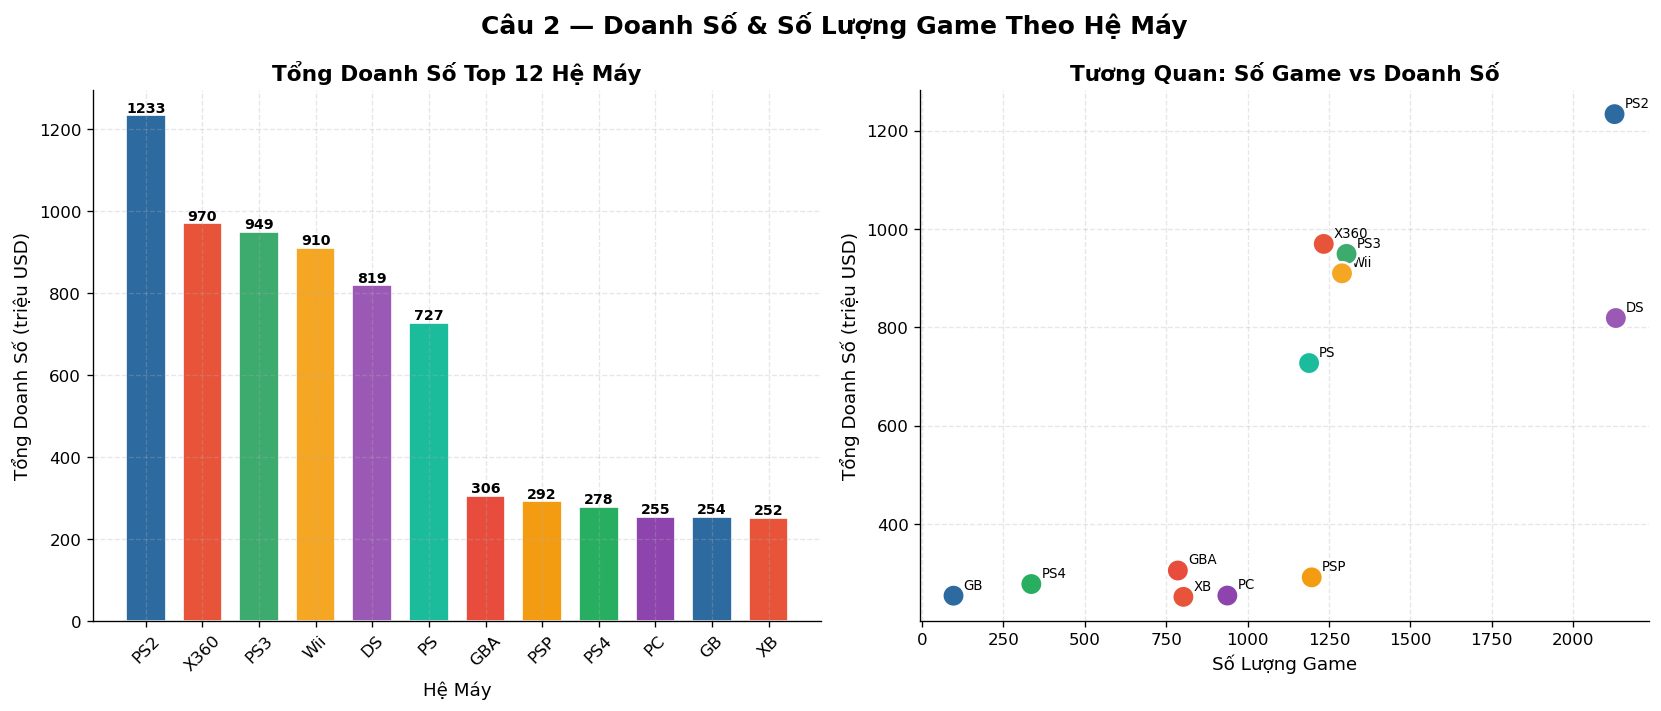


🏆 Hệ máy doanh số cao nhất: PS2 — 1233.46 triệu USD


In [5]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(12)
platform_count = df.groupby('Platform')['Name'].count().reindex(platform_sales.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Câu 2 — Doanh Số & Số Lượng Game Theo Hệ Máy', fontsize=15, fontweight='bold')

# Bar doanh số
bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(platform_sales))]
b1 = axes[0].bar(platform_sales.index, platform_sales.values,
                  color=bar_colors, edgecolor='white', width=0.7)
axes[0].set_xlabel('Hệ Máy', fontsize=11)
axes[0].set_ylabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Tổng Doanh Số Top 12 Hệ Máy', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Scatter doanh số vs số game
axes[1].scatter(platform_count.values, platform_sales.values,
                c=bar_colors, s=180, edgecolors='white', linewidth=1.5, zorder=5)
for i, platform in enumerate(platform_sales.index):
    axes[1].annotate(platform,
                     (platform_count[platform], platform_sales[platform]),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[1].set_xlabel('Số Lượng Game', fontsize=11)
axes[1].set_ylabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[1].set_title('Tương Quan: Số Game vs Doanh Số', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_q2_platform.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n🏆 Hệ máy doanh số cao nhất: {platform_sales.idxmax()} — {platform_sales.max():.2f} triệu USD")

---
## 📊 CÂU HỎI 3 — Nhà phát hành doanh số cao nhất

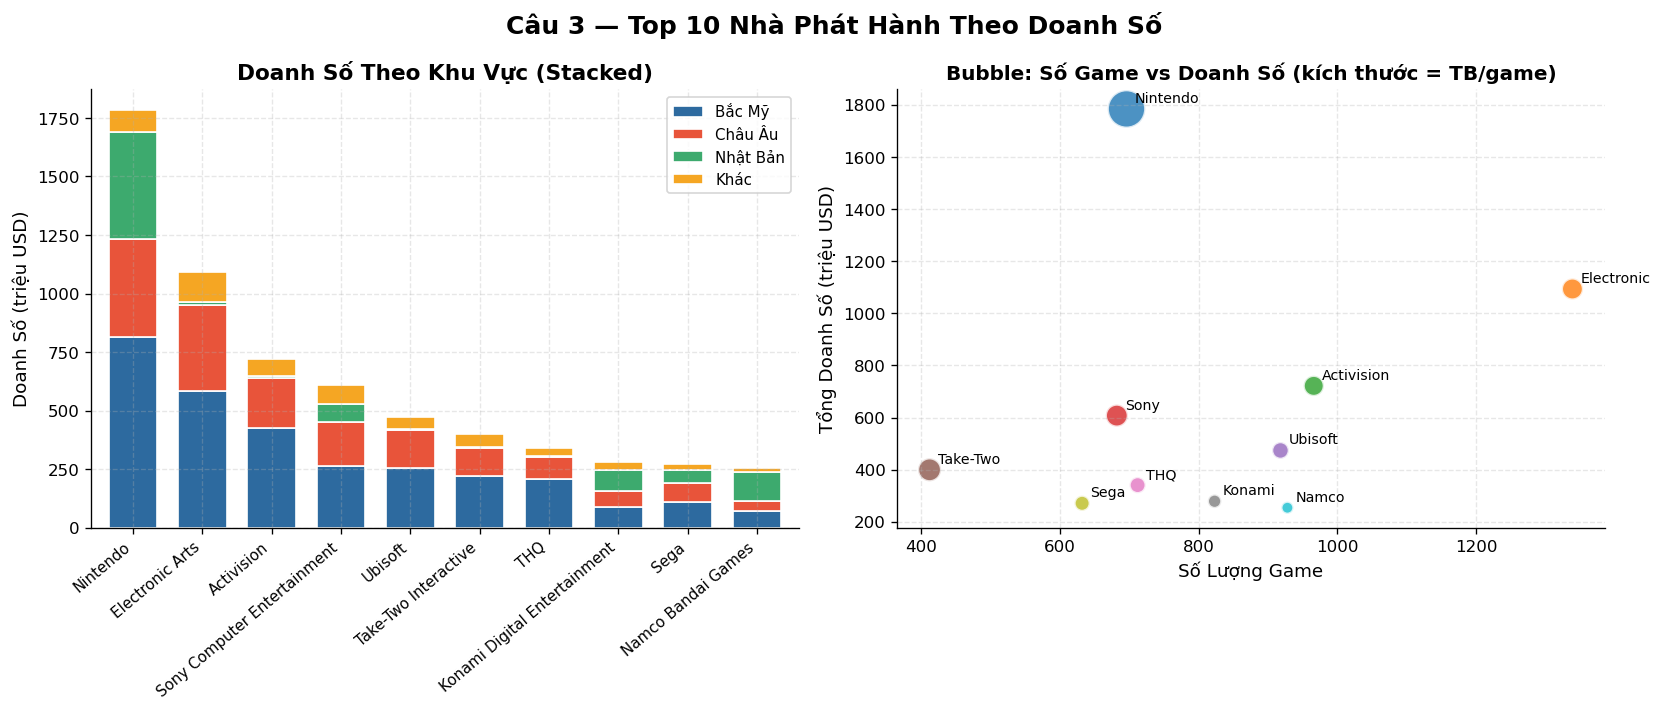


🏆 Nhà phát hành doanh số cao nhất: Nintendo — 1784.43 triệu USD


In [6]:
pub_sales = df.groupby('Publisher').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Num_Games=('Name', 'count'),
    Avg_Sales=('Global_Sales', 'mean')
).sort_values('Total_Sales', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Câu 3 — Top 10 Nhà Phát Hành Theo Doanh Số', fontsize=15, fontweight='bold')

# Stacked bar – doanh số theo khu vực
pub_region = df[df['Publisher'].isin(pub_sales.index)].groupby('Publisher')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
pub_region = pub_region.reindex(pub_sales.index)
pub_region.plot(kind='bar', stacked=True, ax=axes[0],
                color=['#2D6A9F','#E8543A','#3DAA6E','#F5A623'],
                edgecolor='white', width=0.7)
axes[0].set_xticklabels(pub_region.index, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Doanh Số Theo Khu Vực (Stacked)', fontsize=13, fontweight='bold')
axes[0].legend(['Bắc Mỹ','Châu Âu','Nhật Bản','Khác'], loc='upper right', fontsize=9)
axes[0].set_xlabel('')

# Bubble chart
scatter = axes[1].scatter(pub_sales['Num_Games'], pub_sales['Total_Sales'],
                           s=pub_sales['Avg_Sales']*200,
                           c=range(len(pub_sales)), cmap='tab10',
                           alpha=0.8, edgecolors='white', linewidth=1.5)
for i, (pub, row) in enumerate(pub_sales.iterrows()):
    short = pub.split()[0]
    axes[1].annotate(short, (row['Num_Games'], row['Total_Sales']),
                     textcoords='offset points', xytext=(5, 4), fontsize=8.5)
axes[1].set_xlabel('Số Lượng Game', fontsize=11)
axes[1].set_ylabel('Tổng Doanh Số (triệu USD)', fontsize=11)
axes[1].set_title('Bubble: Số Game vs Doanh Số (kích thước = TB/game)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_q3_publisher.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n🏆 Nhà phát hành doanh số cao nhất: {pub_sales['Total_Sales'].idxmax()} — {pub_sales['Total_Sales'].max():.2f} triệu USD")

---
## 📊 CÂU HỎI 4 — Đóng góp của từng khu vực theo thể loại

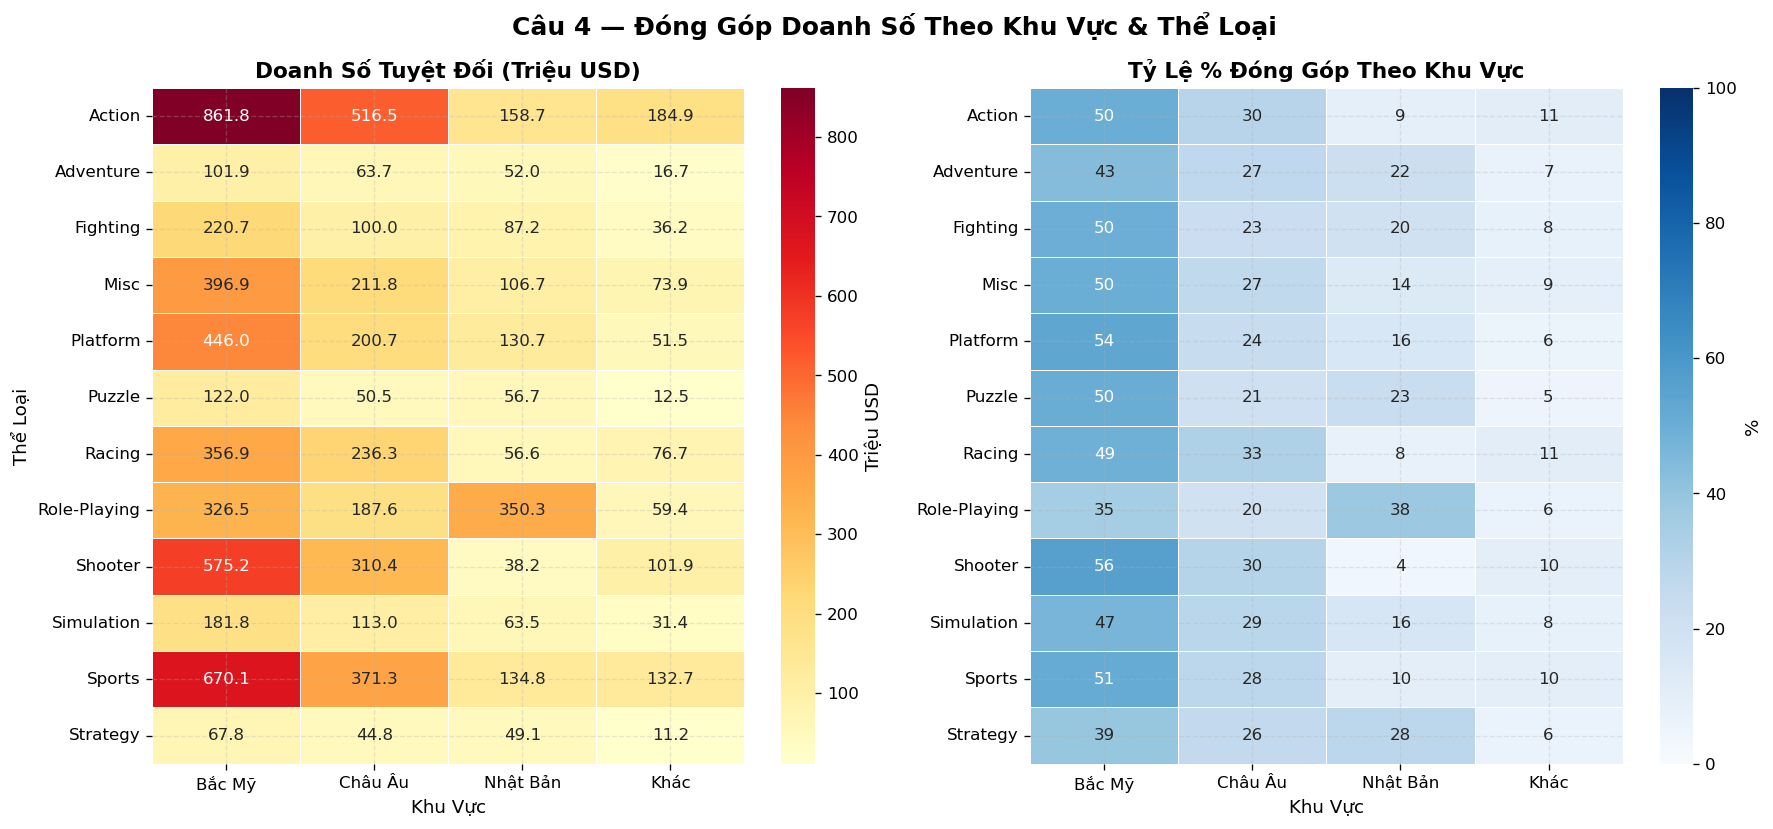

In [7]:
region_genre = df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
region_genre.columns = ['Bắc Mỹ','Châu Âu','Nhật Bản','Khác']
region_genre_pct = region_genre.div(region_genre.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Câu 4 — Đóng Góp Doanh Số Theo Khu Vực & Thể Loại', fontsize=15, fontweight='bold')

# Heatmap doanh số tuyệt đối
sns.heatmap(region_genre, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Triệu USD'})
axes[0].set_title('Doanh Số Tuyệt Đối (Triệu USD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Khu Vực', fontsize=11)
axes[0].set_ylabel('Thể Loại', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# Heatmap tỷ lệ %
sns.heatmap(region_genre_pct, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'label': '%'}, vmin=0, vmax=100)
axes[1].set_title('Tỷ Lệ % Đóng Góp Theo Khu Vực', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Khu Vực', fontsize=11)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart_q4_region.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📊 CÂU HỎI 5 — Xu hướng doanh số theo thời gian

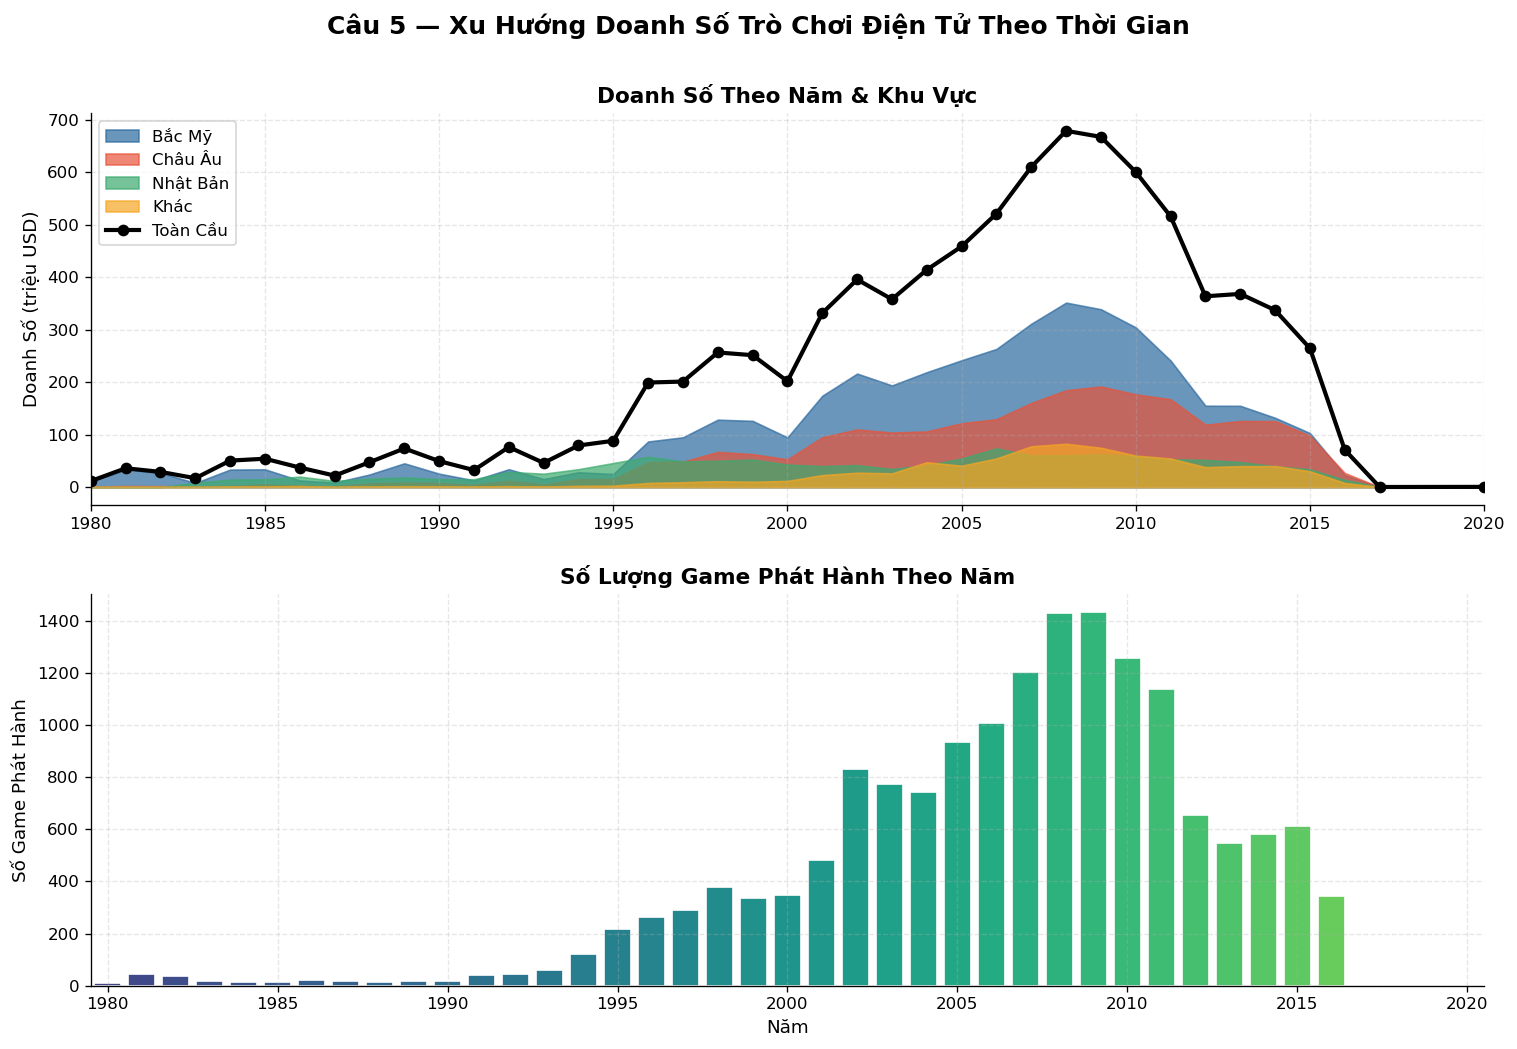

In [8]:
yearly = df.groupby('Year').agg(
    Global=('Global_Sales','sum'),
    NA=('NA_Sales','sum'),
    EU=('EU_Sales','sum'),
    JP=('JP_Sales','sum'),
    Other=('Other_Sales','sum'),
    Count=('Name','count')
).reset_index().sort_values('Year')

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Câu 5 — Xu Hướng Doanh Số Trò Chơi Điện Tử Theo Thời Gian', fontsize=15, fontweight='bold')

# Area chart khu vực
axes[0].fill_between(yearly['Year'], yearly['NA'],  alpha=0.7, color='#2D6A9F', label='Bắc Mỹ')
axes[0].fill_between(yearly['Year'], yearly['EU'],  alpha=0.7, color='#E8543A', label='Châu Âu')
axes[0].fill_between(yearly['Year'], yearly['JP'],  alpha=0.7, color='#3DAA6E', label='Nhật Bản')
axes[0].fill_between(yearly['Year'], yearly['Other'], alpha=0.7, color='#F5A623', label='Khác')
axes[0].plot(yearly['Year'], yearly['Global'], 'k-o', linewidth=2.5, markersize=6,
             zorder=10, label='Toàn Cầu')
axes[0].set_ylabel('Doanh Số (triệu USD)', fontsize=11)
axes[0].set_title('Doanh Số Theo Năm & Khu Vực', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper left')
axes[0].set_xlim(yearly['Year'].min(), yearly['Year'].max())

# Bar chart số game phát hành
bar_colors2 = plt.cm.viridis(np.linspace(0.2, 0.8, len(yearly)))
axes[1].bar(yearly['Year'], yearly['Count'], color=bar_colors2, edgecolor='white', width=0.8)
axes[1].set_xlabel('Năm', fontsize=11)
axes[1].set_ylabel('Số Game Phát Hành', fontsize=11)
axes[1].set_title('Số Lượng Game Phát Hành Theo Năm', fontsize=13, fontweight='bold')
axes[1].set_xlim(yearly['Year'].min()-0.5, yearly['Year'].max()+0.5)

plt.tight_layout(pad=2)
plt.savefig('chart_q5_trend.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🤖 MÔ HÌNH 1 — Hồi quy dự đoán doanh số toàn cầu (Regression)

In [9]:
# Tiền xử lý
df_ml = df[['Genre','Platform','Publisher','Year','NA_Sales','EU_Sales','JP_Sales','Global_Sales']].copy()
df_ml.dropna(inplace=True)

le = LabelEncoder()
for col in ['Genre','Platform','Publisher']:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml[['Genre','Platform','Publisher','Year','NA_Sales','EU_Sales','JP_Sales']]
y = df_ml['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện các mô hình
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R²': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'y_pred': y_pred
    }
    print(f'{name:25s} | R²={results[name]["R²"]:.4f} | RMSE={results[name]["RMSE"]:.4f} | MAE={results[name]["MAE"]:.4f}')

Linear Regression         | R²=0.9952 | RMSE=0.1435 | MAE=0.0267
Random Forest             | R²=0.8217 | RMSE=0.8733 | MAE=0.0508
Gradient Boosting         | R²=0.8510 | RMSE=0.7984 | MAE=0.0519


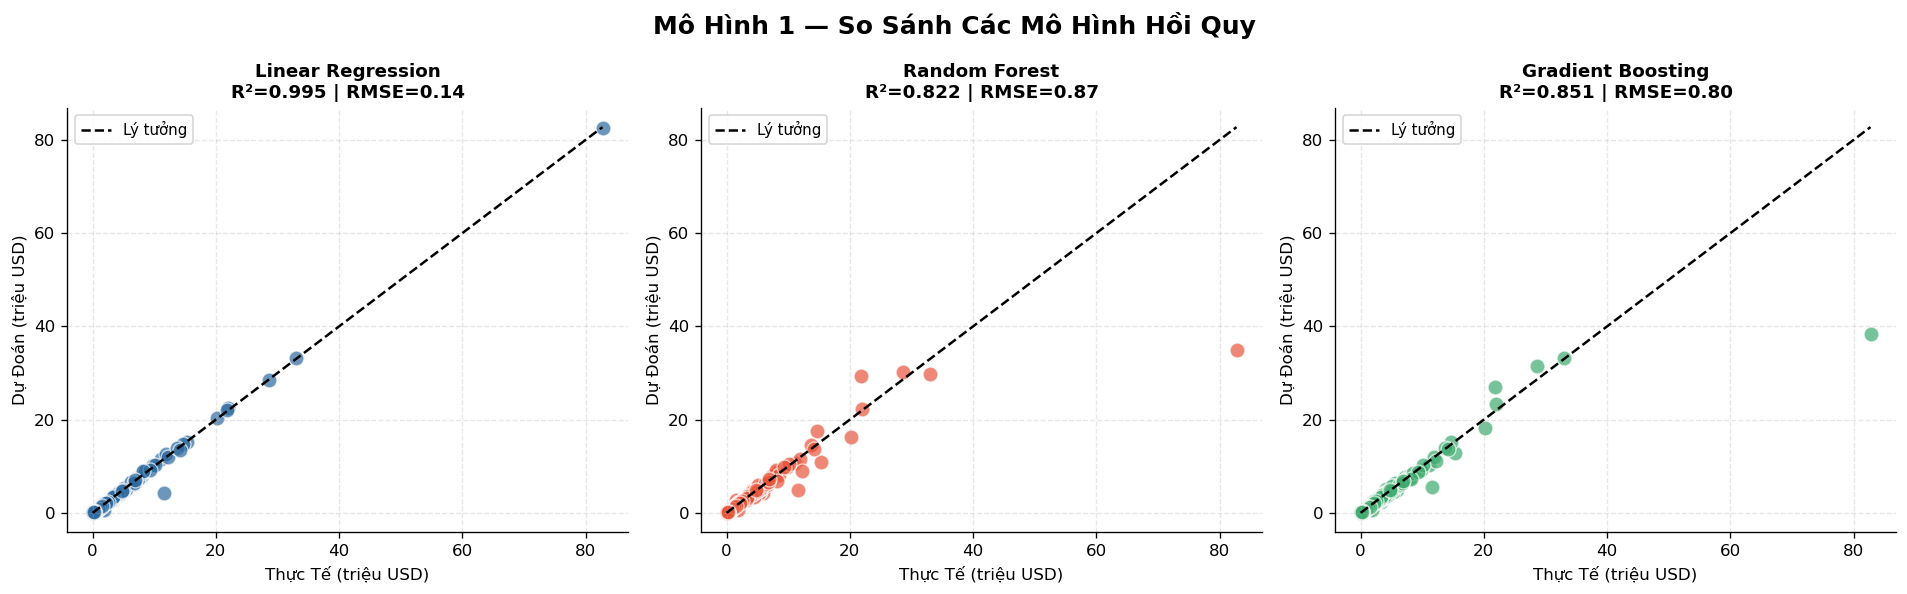

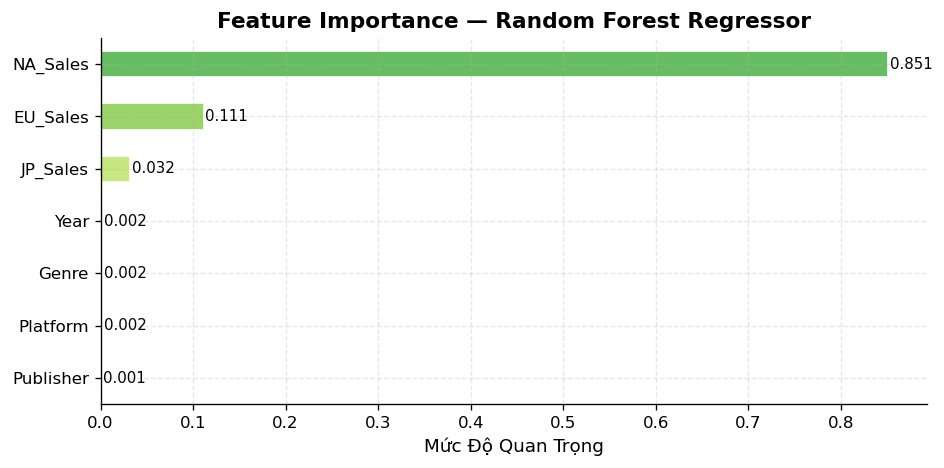

In [10]:
# Trực quan hóa kết quả hồi quy
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mô Hình 1 — So Sánh Các Mô Hình Hồi Quy', fontsize=15, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(y_test, res['y_pred'], alpha=0.7,
               color=PALETTE[i], edgecolors='white', linewidth=0.8, s=80)
    min_v = min(y_test.min(), res['y_pred'].min())
    max_v = max(y_test.max(), res['y_pred'].max())
    ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1.5, label='Lý tưởng')
    ax.set_xlabel('Thực Tế (triệu USD)', fontsize=10)
    ax.set_ylabel('Dự Đoán (triệu USD)', fontsize=10)
    ax.set_title(f'{name}\nR²={res["R²"]:.3f} | RMSE={res["RMSE"]:.2f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart_regression.png', bbox_inches='tight', dpi=150)
plt.show()

# Feature Importance (Random Forest)
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Mức Độ Quan Trọng', fontsize=11)
for bar, val in zip(ax.patches, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🔵 MÔ HÌNH 2 — Phân cụm game theo đặc điểm doanh số (K-Means Clustering)

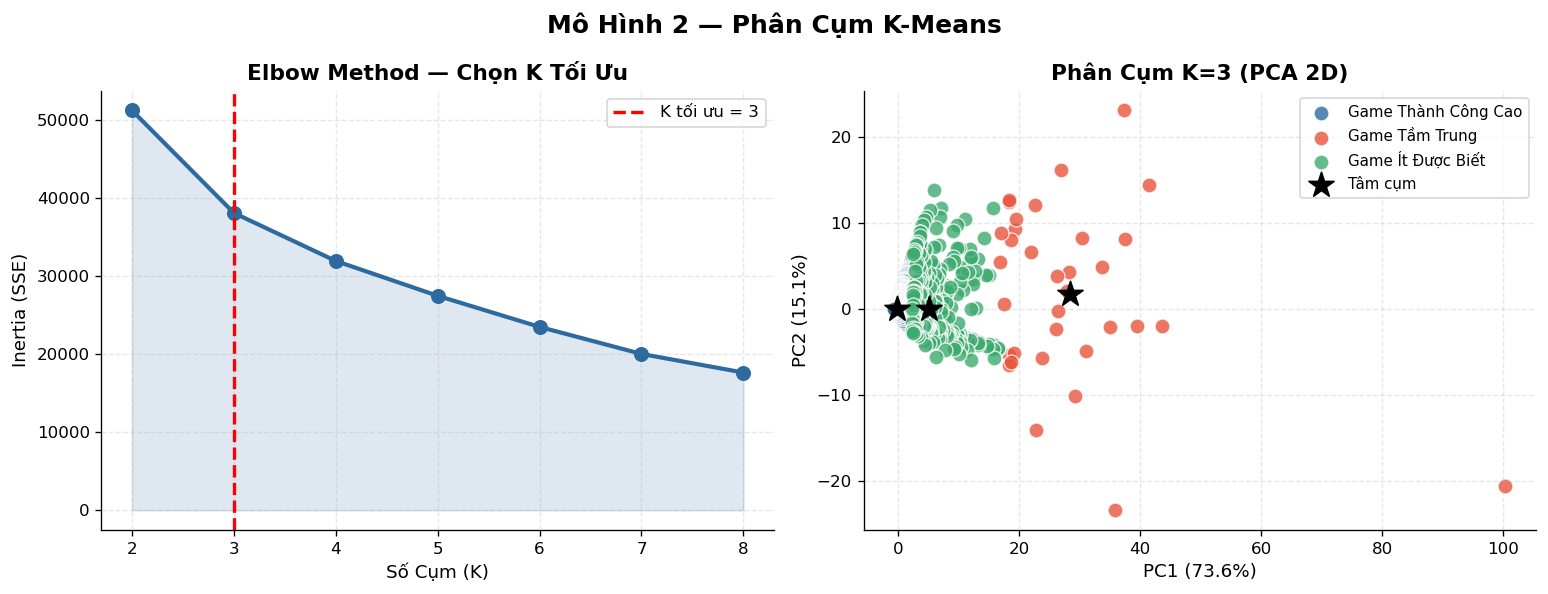


📊 Thống kê theo cụm:
         NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
Cluster                                                         
0            0.17      0.09      0.05         0.03          0.34
1           11.47      6.55      3.46         2.26         23.73
2            2.11      1.45      0.59         0.47          4.61


In [11]:
# Elbow Method chọn K
features_cluster = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']
df_cluster = df[features_cluster].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mô Hình 2 — Phân Cụm K-Means', fontsize=15, fontweight='bold')

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=8, color='#2D6A9F')
axes[0].fill_between(K_range, inertias, alpha=0.15, color='#2D6A9F')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='K tối ưu = 3')
axes[0].set_xlabel('Số Cụm (K)', fontsize=11)
axes[0].set_ylabel('Inertia (SSE)', fontsize=11)
axes[0].set_title('Elbow Method — Chọn K Tối Ưu', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# K=3 clustering với PCA 2D
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_colors = ['#2D6A9F', '#E8543A', '#3DAA6E']
cluster_names  = ['Game Thành Công Cao', 'Game Tầm Trung', 'Game Ít Được Biết']

for i in range(3):
    mask = labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[i], s=80, alpha=0.8,
                    edgecolors='white', linewidth=0.8, label=cluster_names[i])

# Tâm cụm
centers_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centers_pca[:,0], centers_pca[:,1], c='black',
                s=250, marker='*', zorder=10, label='Tâm cụm')

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('Phân Cụm K=3 (PCA 2D)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart_clustering.png', bbox_inches='tight', dpi=150)
plt.show()

# Thêm nhãn cụm vào df
df_cluster = df[features_cluster].dropna().copy()
df_cluster['Cluster'] = labels
print('\n📊 Thống kê theo cụm:')
print(df_cluster.groupby('Cluster')[features_cluster].mean().round(2))

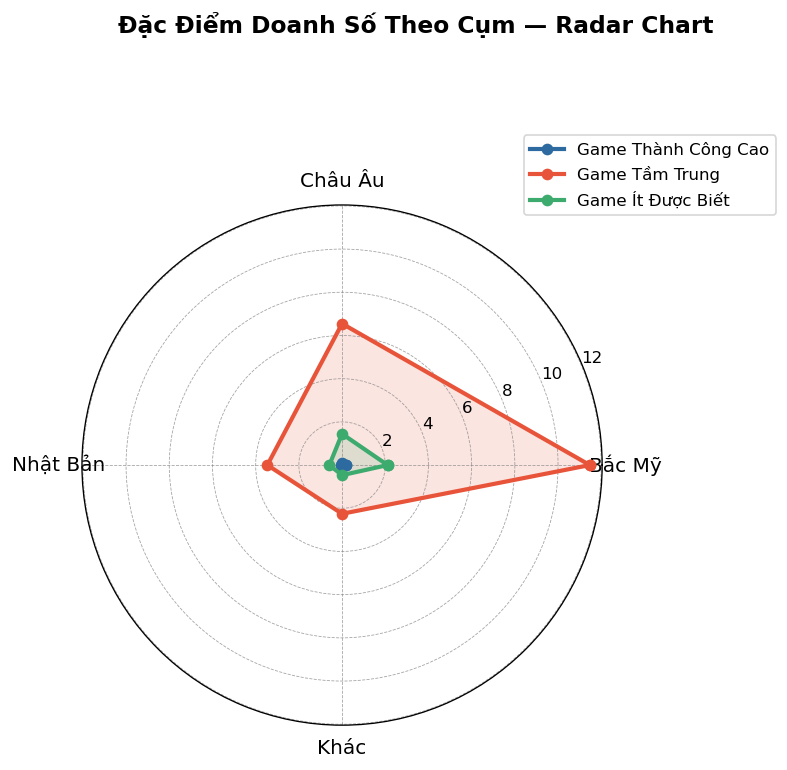

In [12]:
# Radar chart đặc điểm từng cụm
cluster_means = df_cluster.groupby('Cluster')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].mean()

categories = ['Bắc Mỹ', 'Châu Âu', 'Nhật Bản', 'Khác']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('Đặc Điểm Doanh Số Theo Cụm — Radar Chart', fontsize=14, fontweight='bold')

for i, (cid, row) in enumerate(cluster_means.iterrows()):
    vals = row.values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=cluster_colors[i], label=cluster_names[i])
    ax.fill(angles, vals, alpha=0.15, color=cluster_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title('', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('chart_radar.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📋 KẾT LUẬN & ĐÁNH GIÁ

In [13]:
print('='*65)
print('  TỔNG KẾT KẾT QUẢ PHÂN TÍCH')
print('='*65)
print()
print('📊 PHÂN TÍCH DỮ LIỆU:')
print(f'  • Thể loại doanh số cao nhất : {df.groupby("Genre")["Global_Sales"].sum().idxmax()}')
print(f'  • Hệ máy doanh số cao nhất   : {df.groupby("Platform")["Global_Sales"].sum().idxmax()}')
print(f'  • Nhà phát hành dẫn đầu      : {df.groupby("Publisher")["Global_Sales"].sum().idxmax()}')
top_region = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
reg_names = {'NA_Sales':'Bắc Mỹ','EU_Sales':'Châu Âu','JP_Sales':'Nhật Bản','Other_Sales':'Khác'}
print(f'  • Khu vực đóng góp cao nhất  : {reg_names[top_region.idxmax()]} ({top_region.max():.1f}M USD)')
print()
print('🤖 MÔ HÌNH DỰ ĐOÁN (REGRESSION):')
best_model = max(results, key=lambda k: results[k]['R²'])
for name, res in results.items():
    mark = '✅' if name == best_model else '  '
    print(f'  {mark} {name:25s}: R²={res["R²"]:.4f} | RMSE={res["RMSE"]:.4f}')
print(f'  → Mô hình tốt nhất: {best_model}')
print()
print('🔵 PHÂN CỤM (K-MEANS, K=3):')
for i in range(3):
    n = (df_cluster['Cluster'] == i).sum()
    avg = df_cluster[df_cluster['Cluster']==i]['Global_Sales'].mean()
    print(f'  • Cụm {i} — {cluster_names[i]:25s}: {n} game | TB {avg:.2f}M USD')
print()
print('='*65)

  TỔNG KẾT KẾT QUẢ PHÂN TÍCH

📊 PHÂN TÍCH DỮ LIỆU:
  • Thể loại doanh số cao nhất : Action
  • Hệ máy doanh số cao nhất   : PS2
  • Nhà phát hành dẫn đầu      : Nintendo
  • Khu vực đóng góp cao nhất  : Bắc Mỹ (4327.7M USD)

🤖 MÔ HÌNH DỰ ĐOÁN (REGRESSION):
  ✅ Linear Regression        : R²=0.9952 | RMSE=0.1435
     Random Forest            : R²=0.8217 | RMSE=0.8733
     Gradient Boosting        : R²=0.8510 | RMSE=0.7984
  → Mô hình tốt nhất: Linear Regression

🔵 PHÂN CỤM (K-MEANS, K=3):
  • Cụm 0 — Game Thành Công Cao      : 15687 game | TB 0.34M USD
  • Cụm 1 — Game Tầm Trung           : 34 game | TB 23.73M USD
  • Cụm 2 — Game Ít Được Biết        : 570 game | TB 4.61M USD

